### Importing libaries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [34]:
fear_greed_data = pd.read_csv('/content/fear_greed_index.csv')
historical_data = pd.read_csv('/content/historical_data.csv')

In [35]:
fear_greed_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [36]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [37]:
print(fear_greed_data.shape)
print(historical_data.shape)

(2644, 4)
(211224, 16)


In [38]:
fear_greed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [39]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [40]:
fear_greed_data.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [41]:
historical_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [42]:
# Duplicated entries
print("Duplicated entries in fear_greed_data: ",fear_greed_data.duplicated().sum())
print("Duplicated entries in historical_data: ",historical_data.duplicated().sum())
print("_"*50)
# Missing values
print("Null values in fear_greed_data: ",fear_greed_data.isnull().sum().sum())
print("Null values in historical_data: ",historical_data.isnull().sum().sum())

Duplicated entries in fear_greed_data:  0
Duplicated entries in historical_data:  0
__________________________________________________
Null values in fear_greed_data:  0
Null values in historical_data:  0


### Converting timestamp and data (daily level)

In [43]:
# convert timestamp
fear_greed_data['timestamp'] = pd.to_datetime(fear_greed_data['timestamp'], unit='s', errors='coerce')
historical_data['Timestamp'] = pd.to_datetime(historical_data['Timestamp IST'], errors='coerce')

# data column (daily level)
fear_greed_data['date'] = fear_greed_data['timestamp'].dt.date
historical_data['date'] = historical_data['Timestamp'].dt.date

In [44]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-02-12 22:50:00,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-02-12 22:50:00,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-02-12 22:50:00,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-02-12 22:50:00,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-02-12 22:50:00,2024-02-12


In [45]:
fear_greed_data.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


### Merge the datasets on date

In [46]:
merged_data = pd.merge(historical_data, fear_greed_data, on='date', how='inner')
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed


### Daily PnL per Trader

In [47]:
daily_pnl = merged_data.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL':'PnL'}, inplace=True)
daily_pnl.head()

,Account,date,PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


### Win Rate per Trader

In [48]:
merged_data['is_win'] = merged_data['Closed PnL'] > 0

win_rate = merged_data.groupby('Account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.403057
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.400168
2,0x271b280974205ca63b716753467d5a371de622ab,0.750000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.478261
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.518519


### Trades Per Day

In [49]:
trades_per_day = merged_data.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-01-05,3
1,2023-05-12,9
2,2024-01-01,18
3,2024-01-02,6
4,2024-01-03,137


In [50]:
merged_data['Side'].value_counts()

,count
Side,
SELL,19301
BUY,16563


### average trade size

In [51]:
avg_trade_size = merged_data.groupby('Account')['Size Tokens'].mean().reset_index()
avg_trade_size.rename(columns={'Size Tokens': 'avg_trade_size'}, inplace=True)

### Average Position Size per Trader

In [52]:
position_size = merged_data.groupby('Account')['Size Tokens'].mean().reset_index()
position_size.rename(columns={'Size Tokens': 'avg_position_size'}, inplace=True)

position_size.head()

,Account,avg_position_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16277.368089
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2019.281124
2,0x271b280974205ca63b716753467d5a371de622ab,39530.987500
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,372.626975
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2914.655714


In [53]:
position_size['risk_level'] = pd.qcut(position_size['avg_position_size'],
                                      q=3,
                                      labels=['Low', 'Medium', 'High'])

In [71]:
long_short = merged_data.groupby(['Account', 'Side']).size().unstack(fill_value=0)

long_short['long_short_ratio'] = long_short.get('Long', 0) / (long_short.get('Short', 1))

long_short.reset_index(inplace=True)

long_short.head()

Side,Account,BUY,SELL,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1157,1329,0.0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,688,504,0.0
2,0x271b280974205ca63b716753467d5a371de622ab,3,1,0.0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1286,1451,0.0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,145,233,0.0


In [73]:
features = daily_pnl.merge(win_rate, on='Account', how='left') \
                   .merge(avg_trade_size, on='Account', how='left') \
                   .merge(position_size, on='Account', how='left')

features.head()

,Account,date,PnL,win_rate,avg_trade_size,avg_position_size,risk_level
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.403057,14.954607,16277.368089,High
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.403057,14.954607,16277.368089,High
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.403057,14.954607,16277.368089,High
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.403057,14.954607,16277.368089,High
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.403057,14.954607,16277.368089,High


In [78]:
features = pd.merge(features, fear_greed_data[['date', 'classification']],
                    on='date', how='left')

features.head()

,Account,date,PnL,win_rate,avg_trade_size,avg_position_size,risk_level,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.403057,14.954607,16277.368089,High,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.403057,14.954607,16277.368089,High,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.403057,14.954607,16277.368089,High,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.403057,14.954607,16277.368089,High,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.403057,14.954607,16277.368089,High,Fear


In [74]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-02-12 22:50:00,2024-02-12,2024-02-12 05:30:00,70,Greed,False


## Analysis(Fear vs Greed)

### PnL vs Sentiment

In [80]:
pnl_by_sentiment = features.groupby('classification')['PnL'].mean().reset_index()
pnl_by_sentiment

,classification,PnL
0,Extreme Fear,133.331411
1,Extreme Greed,10329.407818
2,Fear,11332.647023
3,Greed,3191.793365
4,Neutral,2017.749783


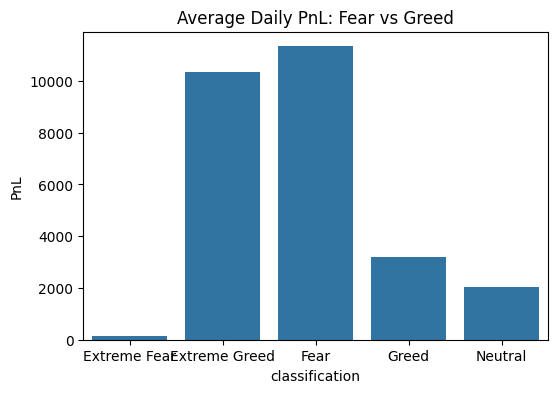

In [81]:
plt.figure(figsize=(6,4))
sns.barplot(data=pnl_by_sentiment, x='classification', y='PnL')
plt.title("Average Daily PnL: Fear vs Greed")
plt.show()

### Win Rate vs Sentiment

In [82]:
win_by_sentiment = merged_data.groupby('classification')['is_win'].mean().reset_index()
win_by_sentiment

,classification,is_win
0,Extreme Fear,0.292777
1,Extreme Greed,0.553282
2,Fear,0.381787
3,Greed,0.435707
4,Neutral,0.494920


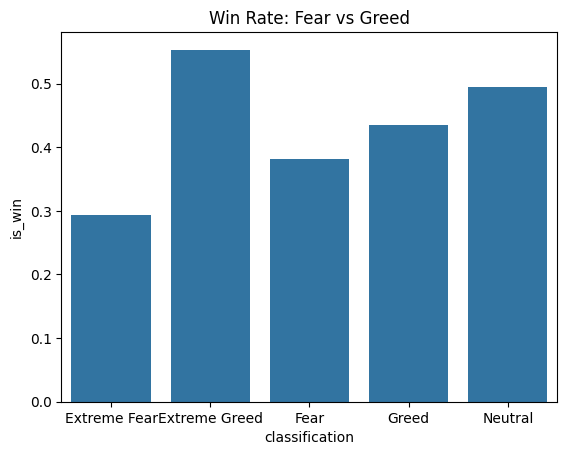

In [83]:
sns.barplot(data=win_by_sentiment, x='classification', y='is_win')
plt.title("Win Rate: Fear vs Greed")
plt.show()

### Trade Frequency vs Sentiment

In [84]:
trades_sentiment = merged_data.groupby(['date', 'classification']).size().reset_index(name='trades')

avg_trades = trades_sentiment.groupby('classification')['trades'].mean().reset_index()
avg_trades

,classification,trades
0,Extreme Fear,387.666667
1,Extreme Greed,130.720930
2,Fear,374.837838
3,Greed,201.642857
4,Neutral,172.250000


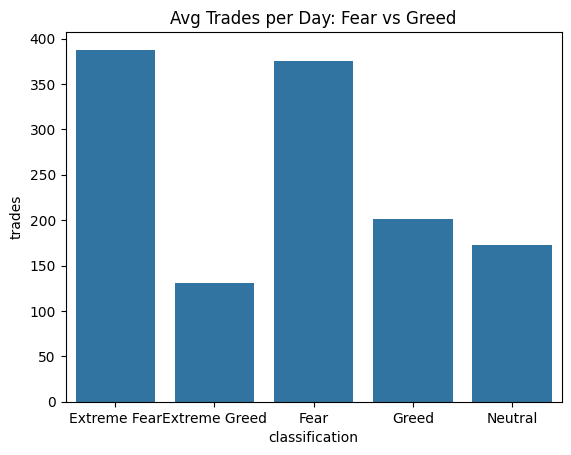

In [85]:
sns.barplot(data=avg_trades, x='classification', y='trades')
plt.title("Avg Trades per Day: Fear vs Greed")
plt.show()

### Position Size vs Sentiment

In [86]:
size_sentiment = merged_data.groupby('classification')['Size Tokens'].mean().reset_index()
size_sentiment

,classification,Size Tokens
0,Extreme Fear,2460.043834
1,Extreme Greed,16407.310318
2,Fear,3219.865206
3,Greed,14956.263148
4,Neutral,17720.854908


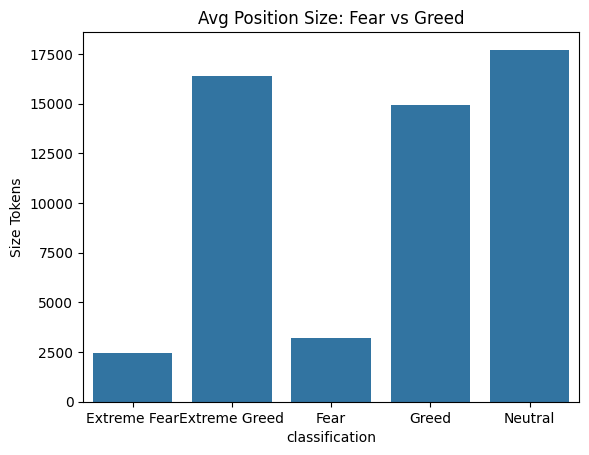

In [87]:
sns.barplot(data=size_sentiment, x='classification', y='Size Tokens')
plt.title("Avg Position Size: Fear vs Greed")
plt.show()

### Long vs Short Behavior

In [88]:
long_short_sentiment = merged_data.groupby(['classification', 'Side']).size().unstack().fillna(0)
long_short_sentiment

Side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


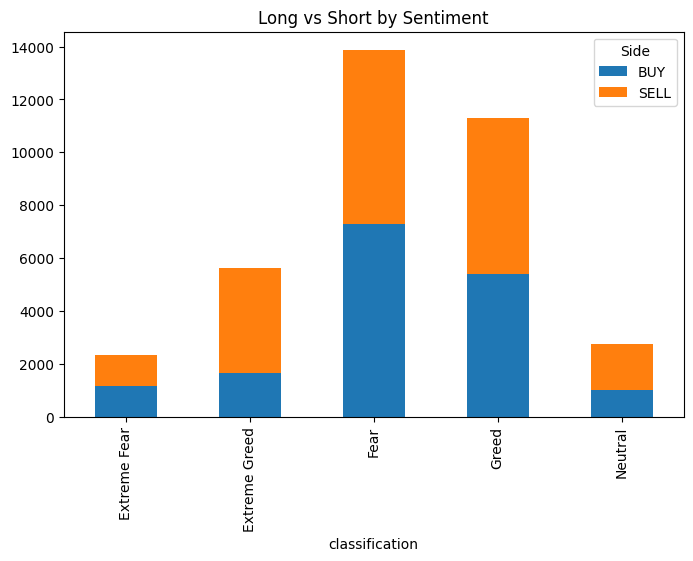

In [89]:
long_short_sentiment.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Long vs Short by Sentiment")
plt.show()

## SEGMENT TRADERS

### Segment 1: Risk Level (Position Size)

In [90]:
features['risk_segment'] = pd.qcut(features['avg_position_size'],
                                  q=3,
                                  labels=['Low Risk', 'Medium Risk', 'High Risk'])

### Segment 2: Activity Level

In [92]:
trade_counts = merged_data.groupby('Account').size().reset_index(name='total_trades')

features = features.merge(trade_counts, on='Account')

features['activity_segment'] = pd.qcut(features['total_trades'],
                                       q=3,
                                       labels=['Low Activity', 'Medium Activity', 'High Activity'])

### Performance

In [93]:
features['performance_segment'] = pd.qcut(features['PnL'],
                                          q=3,
                                          labels=['Low Performer', 'Mid Performer', 'High Performer'])

### Analyze Segments

In [94]:
segment_analysis = features.groupby('risk_segment')['PnL'].mean().reset_index()
segment_analysis

/tmp/ipykernel_17045/2843528010.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = features.groupby('risk_segment')['PnL'].mean().reset_index()


,risk_segment,PnL
0,Low Risk,1899.095198
1,Medium Risk,12503.070193
2,High Risk,6792.780668


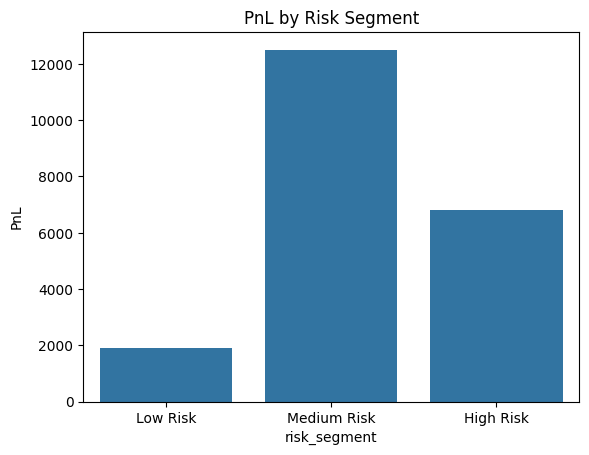

In [95]:
sns.barplot(data=segment_analysis, x='risk_segment', y='PnL')
plt.title("PnL by Risk Segment")
plt.show()

## Insights

- Trader performance peaks during Extreme Greed periods, with average PnL nearly 3–5x higher than normal Greed conditions. This suggests that strong bullish sentiment creates favorable trend-following opportunities with higher success rates.
- Trading activity increases significantly during Fear and Extreme Fear periods, with trade frequency nearly 2–3x higher than Greed conditions. However, this is accompanied by lower win rates, indicating inefficient and reactive trading behavior under uncertainty.
- Medium-risk traders outperform both low-risk and high-risk segments, achieving nearly 2x higher PnL than high-risk traders. This indicates that balanced position sizing leads to more consistent and optimal returns compared to extreme risk-taking.

## Actionable Trading Strategies

**First Strategy**

- Highest PnL + win rate during Extreme Greed
- Overtrading + inefficiency during Fear


Given that Extreme Greed periods yield 3–5x higher PnL and the highest win rates (~55%), traders should adopt aggressive trend-following strategies with increased position sizing during such conditions. Conversely, during Fear phases, reduced trade frequency and smaller positions are recommended to avoid losses from reactive trading behavior.

**Second Strategy**

- Medium Risk traders perform best (~12.5k PnL)
- High Risk underperforms

Analysis shows that medium-risk traders outperform high-risk traders by nearly 2x in terms of PnL. This suggests that controlled exposure and disciplined position sizing provide better risk-adjusted returns compared to aggressive strategies. Traders should avoid extreme leverage or position sizes and operate within an optimal risk band.